In [2]:
import pandas as pd #used for data manipulation and analysis, providing data structures like DataFrames to handle tabular data efficiently
import numpy as np #used for numerical operations and array manipulation, providing support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays

from sklearn.model_selection import train_test_split #used to split the dataset into training and testing sets, allowing for the evaluation of the model's performance on unseen data
from sklearn.preprocessing import LabelEncoder #used to convert categorical labels into numerical format, which is necessary for machine learning algorithms that require numerical input
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier #used to create an XGBoost classifier, which is an optimized gradient boosting algorithm that can be used for classification tasks, providing high performance and efficiency   

LOADING THE DATASET

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv( #used to read the CSV file from the specified URL and load it into a DataFrame
    url,
    sep=';',
    header=None
)

print(data.shape)

(1055, 42)


FEATURES & LABELS

In [4]:
X = data.iloc[:, :-1] #used to select all columns except the last one as features (X) for the machine learning model, which will be used to predict the target variable (y)
y = data.iloc[:, -1] #used to select the last column as the target variable (y) for the machine learning model

encoder = LabelEncoder() #used to convert the categorical labels in the target variable (y) into numerical format, which is necessary for machine learning algorithms that require numerical input. The fit_transform method is used to fit the encoder to the data and transform it in one step.
y = encoder.fit_transform(y) #used to fit the LabelEncoder to the target variable (y) and transform the categorical labels into numerical format, which is necessary for machine learning algorithms that require numerical input

TRAIN/TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split( #used to split the dataset into training and testing sets, allowing for the evaluation of the model's performance on unseen data. The test_size parameter specifies the proportion of the dataset to include in the test split, random_state is used for reproducibility, and stratify ensures that the class distribution is preserved in both training and testing sets.
    X,
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y #used to ensure that the class distribution is preserved in both training and testing sets, which is important for imbalanced datasets to prevent bias in the model's performance evaluation
)

XGBOOST MODEL

In [6]:
xgb_model = XGBClassifier( #used to create an XGBoost classifier with specified hyperparameters, including n_estimators for the number of boosting rounds, max_depth for the maximum depth of the trees, learning_rate for the step size shrinkage, objective for the learning task and corresponding learning objective, eval_metric for the evaluation metric to be used during training, and random_state for reproducibility
    n_estimators=100, #used to specify the number of boosting rounds or trees to be built in the XGBoost model, which can affect the model's performance and complexity
    max_depth=4, #used to specify the maximum depth of the trees in the XGBoost model, which can affect the model's performance and complexity
    learning_rate=0.1, #used to specify the step size shrinkage used in the XGBoost model, which can help prevent overfitting by reducing the contribution of each tree
    objective='binary:logistic', #used to specify the learning task and corresponding learning objective for the XGBoost model, in this case, binary classification with logistic regression
    eval_metric='logloss', #used to specify the evaluation metric to be used during training of the XGBoost model, in this case, log loss which is commonly used for binary classification problems
    random_state=42 #used for reproducibility of the results
)

TRAINING & PREDICTION

In [7]:
xgb_model.fit(X_train, y_train) #used to fit the XGBoost model to the training data (X_train and y_train), allowing the model to learn the patterns in the data and make predictions on unseen data (X_test)


y_pred = xgb_model.predict(X_test) #used to make predictions on the test set (X_test) using the fitted XGBoost model, which will output the predicted class labels for each instance in the test set
y_prob = xgb_model.predict_proba(X_test)[:, 1] #used to predict the probabilities of the positive class (class 1) for each instance in the test set (X_test) using the fitted XGBoost model. The predict_proba method returns an array of shape (n_samples, n_classes) with the predicted probabilities for each class, and [:, 1] is used to select the probabilities for the positive class (class 1) which is typically used for binary classification problems when calculating metrics like ROC AUC score.

ACCURACY

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8720379146919431


CONFUSION MATRIX & CLASSIFICATION REPORT

In [9]:
cm = confusion_matrix(y_test, y_pred) #used to compute the confusion matrix, which is a table that summarizes the performance of a classification model by showing the counts of true positive, true negative, false positive, and false negative predictions. It helps to evaluate the accuracy and performance of the model in terms of its ability to correctly classify instances into their respective classes.

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()


print("\nClassification Report\n")

print(
    classification_report( #used to generate a classification report, which provides a detailed summary of the precision, recall, F1-score, and support for each class in a classification model. It helps to evaluate the performance of the model in terms of its ability to correctly classify instances into their respective classes.
        y_test,
        y_pred,
        target_names=['Non-Biodegradable', 'Biodegradable'],
        digits=4
    )
)

NameError: name 'plt' is not defined

ROC CURVE

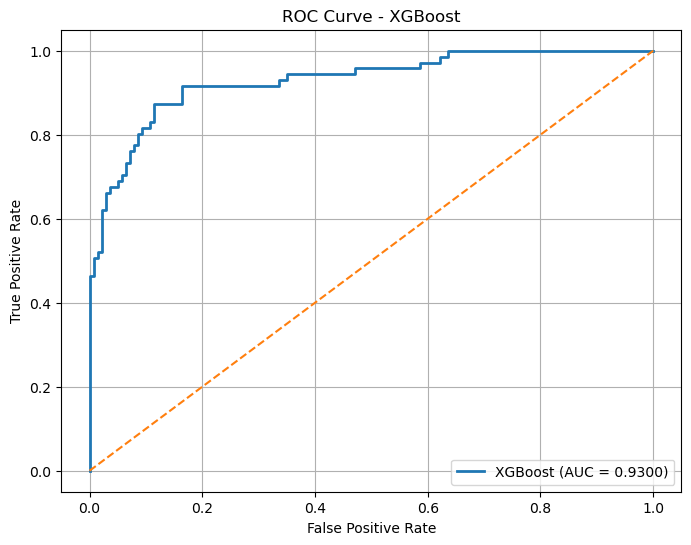

In [ ]:

# Predicted probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
#references: https://github.com/pritampanda15/Omixium_YouTube_Channel/blob/main/QSAR_data/saved_models/LogP_XGBoost.pkl